# Week 5 Internship Task: Natural Language Processing & Sentiment Analysis

**Objective**: Build an end-to-end NLP sentiment classification pipeline on real Amazon product customer reviews. Clean raw text, convert to TF-IDF numerical vectors, train multiple text classification models, evaluate performance, and save the best performing model artifact.

---
## Part 1 Pipeline Roadmap
1. Data Loading & Exploratory Data Analysis (EDA)
2. Text Cleaning & Preprocessing (Noise reduction, Stopword removal, Lemmatization)
3. Exploratory Text Visualizations (Positive & Negative Word Clouds)
4. Feature Extraction using TF-IDF Vectorization
5. Train-Test Data Splitting
6. Model Training (Logistic Regression, Naive Bayes, Random Forest)
7. Model Evaluation & Confusion Matrix Visualizations
8. Model & Vectorizer Export for Streamlit Dashboard


In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)

# Add parent directory to path to import modular cleaner
sys.path.append(os.path.abspath('..'))
from utils.nlp_cleaner import clean_text

# Style configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'Segoe UI'
plt.rcParams['font.size'] = 11
print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Dataset Loading & Inspection

We load the **Amazon Product Reviews Dataset** (`DataSet (W5).csv`) and inspect its structural properties, columns, and feedback sentiment distribution.


In [2]:
data_path = os.path.join('..', 'data', 'DataSet (W5).csv')
if not os.path.exists(data_path):
    data_path = os.path.join('data', 'DataSet (W5).csv')

df = pd.read_csv(data_path)

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape: (3150, 5)

First 5 Rows:


,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB

Missing Values:
rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64


,Count,Percentage (%)
Positive (1),2893,91.84127
Negative (0),257,8.15873


C:\Users\Amin Khan\AppData\Local\Temp\ipykernel_6348\608553362.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=dist_df.index, y=dist_df['Count'], palette=['#2ecc71', '#e74c3c'])


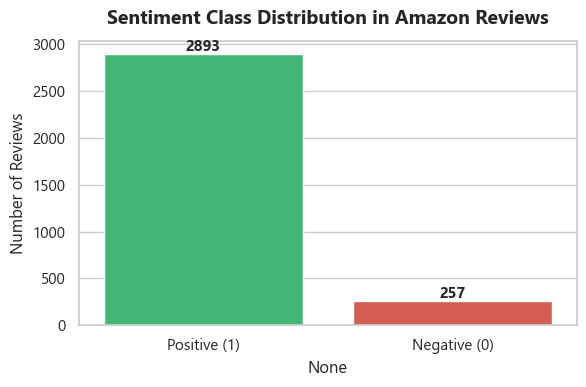

In [3]:
# Inspect class distribution of 'feedback' label (1 = Positive, 0 = Negative)
feedback_counts = df['feedback'].value_counts()
feedback_pct = df['feedback'].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({'Count': feedback_counts, 'Percentage (%)': feedback_pct})
dist_df.index = ['Positive (1)', 'Negative (0)']
display(dist_df)

# Plot class distribution
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=dist_df.index, y=dist_df['Count'], palette=['#2ecc71', '#e74c3c'])
plt.title('Sentiment Class Distribution in Amazon Reviews', fontsize=14, fontweight='bold', pad=12)
plt.ylabel('Number of Reviews')
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')
plt.tight_layout()
plt.show()


## 2. Text Cleaning & Preprocessing

Raw text in customer reviews contains noise such as HTML tags, URLs, special characters, numbers, and common English stopwords ('the', 'is', 'and') that carry minimal sentiment signal.

We apply a comprehensive cleaning pipeline using our modular function `clean_text()`:
- Lowercasing
- Removal of HTML tags, URLs, numbers, and special characters
- Tokenization & stopword removal
- Wordnet Lemmatization (reducing words to canonical base forms)


In [4]:
# Apply cleaning to verified_reviews
df['cleaned_reviews'] = df['verified_reviews'].astype(str).apply(clean_text)

# Inspect before and after cleaning samples
sample_comparison = df[['verified_reviews', 'cleaned_reviews', 'feedback']].head(5)
for idx, row in sample_comparison.iterrows():
    print(f"--- Sample {idx+1} [Sentiment: {row['feedback']}] ---")
    print(f"RAW    : {row['verified_reviews']}")
    print(f"CLEANED: {row['cleaned_reviews']}\n")


--- Sample 1 [Sentiment: 1] ---
RAW    : Love my Echo!
CLEANED: love echo

--- Sample 2 [Sentiment: 1] ---
RAW    : Loved it!
CLEANED: loved

--- Sample 3 [Sentiment: 1] ---
RAW    : Sometimes while playing a game, you can answer a question correctly but Alexa says you got it wrong and answers the same as you.  I like being able to turn lights on and off while away from home.
CLEANED: sometimes playing game answer question correctly alexa says got wrong answers like able turn lights away home

--- Sample 4 [Sentiment: 1] ---
RAW    : I have had a lot of fun with this thing. My 4 yr old learns about dinosaurs, i control the lights and play games like categories. Has nice sound when playing music as well.
CLEANED: lot fun thing old learns dinosaurs control lights play games like categories nice sound playing music well

--- Sample 5 [Sentiment: 1] ---
RAW    : Music
CLEANED: music



## 3. Word Cloud Visualizations

We generate two separate Word Clouds to contrast the most frequent and salient terms present in **Positive Reviews** versus **Negative Reviews**.


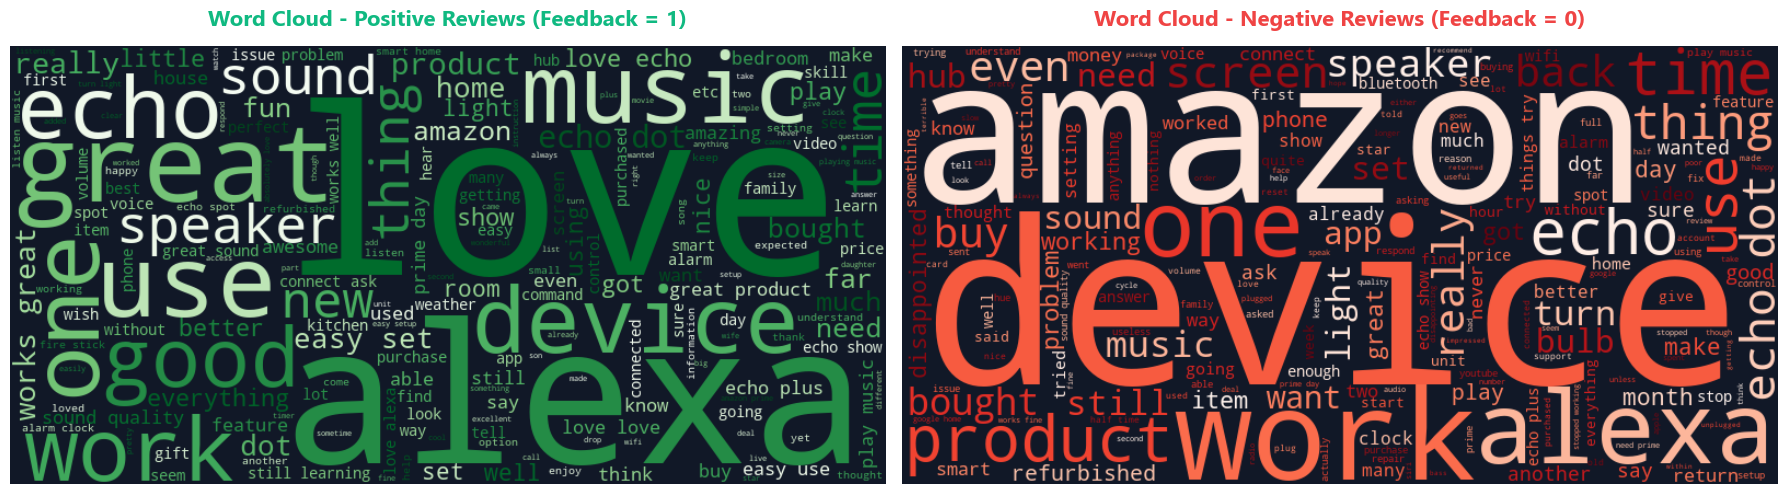

In [5]:
pos_text = " ".join(df[df['feedback'] == 1]['cleaned_reviews'])
neg_text = " ".join(df[df['feedback'] == 0]['cleaned_reviews'])

wc_pos = WordCloud(width=800, height=400, background_color='#111827', colormap='Greens').generate(pos_text)
wc_neg = WordCloud(width=800, height=400, background_color='#111827', colormap='Reds').generate(neg_text)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Word Cloud - Positive Reviews (Feedback = 1)', fontsize=16, fontweight='bold', color='#10B981', pad=15)
axes[0].axis('off')

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Word Cloud - Negative Reviews (Feedback = 0)', fontsize=16, fontweight='bold', color='#EF4444', pad=15)
axes[1].axis('off')

plt.tight_layout()
plt.show()


## 4. Text Vectorization: TF-IDF (Term Frequency-Inverse Document Frequency)

### Why TF-IDF was chosen:
1. **Downweighting Frequent Terms**: Unlike simple Bag-of-Words (CountVectorizer) which counts raw word frequencies, **TF-IDF** penalizes words that appear frequently across *all* documents (e.g., product names like "echo", "alexa" or general words like "got").
2. **Highlighting Discriminative Words**: Words that appear frequently in a *specific* review but rarely across the entire corpus receive higher TF-IDF weights, directly sharpening the classifier's ability to pick up strong sentiment indicators (e.g., "defective", "amazing", "refused").
3. **N-Gram Support**: We include unigrams and bigrams (`ngram_range=(1, 2)`), capturing key two-word sentiment patterns like "not working" or "great product".


In [6]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df['cleaned_reviews'])
y = df['feedback']

print(f"TF-IDF Feature Matrix Shape: {X.shape}")
print("Sample extracted features (first 20 vocabulary items):")
print(vectorizer.get_feature_names_out()[:20])


TF-IDF Feature Matrix Shape: (3150, 5000)
Sample extracted features (first 20 vocabulary items):
['abilities' 'ability' 'ability play' 'able' 'able connect' 'able control'
 'able download' 'able downloaded' 'able follow' 'able hear' 'able listen'
 'able play' 'able see' 'able set' 'able tell' 'able use' 'able watch'
 'absolutely' 'absolutely amazing' 'absolutely great']


## 5. Train-Test Dataset Splitting

We perform an 80/20 train-test split using **stratified sampling** to maintain identical class ratios in both training and test sets.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size : {X_test.shape[0]} samples")


Training set size: 2520 samples
Testing set size : 630 samples


## 6. Model Training & Evaluation

We train and compare three distinct classification algorithms:
1. **Logistic Regression**: Linear baseline well-suited for high-dimensional text vectors.
2. **Multinomial Naive Bayes**: Probabilistic model suited for word frequency distributions.
3. **Random Forest Classifier**: Non-linear ensemble model capturing non-linear feature interactions.


In [8]:
models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Multinomial Naive Bayes': MultinomialNB(alpha=0.5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
confusion_matrices = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else 0.0
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    }
    confusion_matrices[name] = cm

    print(f"=== {name} Classification Report ===")
    print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Positive (1)']))


=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

Negative (0)       1.00      0.02      0.04        51
Positive (1)       0.92      1.00      0.96       579

    accuracy                           0.92       630
   macro avg       0.96      0.51      0.50       630
weighted avg       0.93      0.92      0.88       630

=== Multinomial Naive Bayes Classification Report ===
              precision    recall  f1-score   support

Negative (0)       1.00      0.12      0.21        51
Positive (1)       0.93      1.00      0.96       579

    accuracy                           0.93       630
   macro avg       0.96      0.56      0.59       630
weighted avg       0.93      0.93      0.90       630



=== Random Forest Classification Report ===
              precision    recall  f1-score   support

Negative (0)       0.92      0.24      0.38        51
Positive (1)       0.94      1.00      0.97       579

    accuracy                           0.94       630
   macro avg       0.93      0.62      0.67       630
weighted avg       0.94      0.94      0.92       630



### Confusion Matrix Visualizations

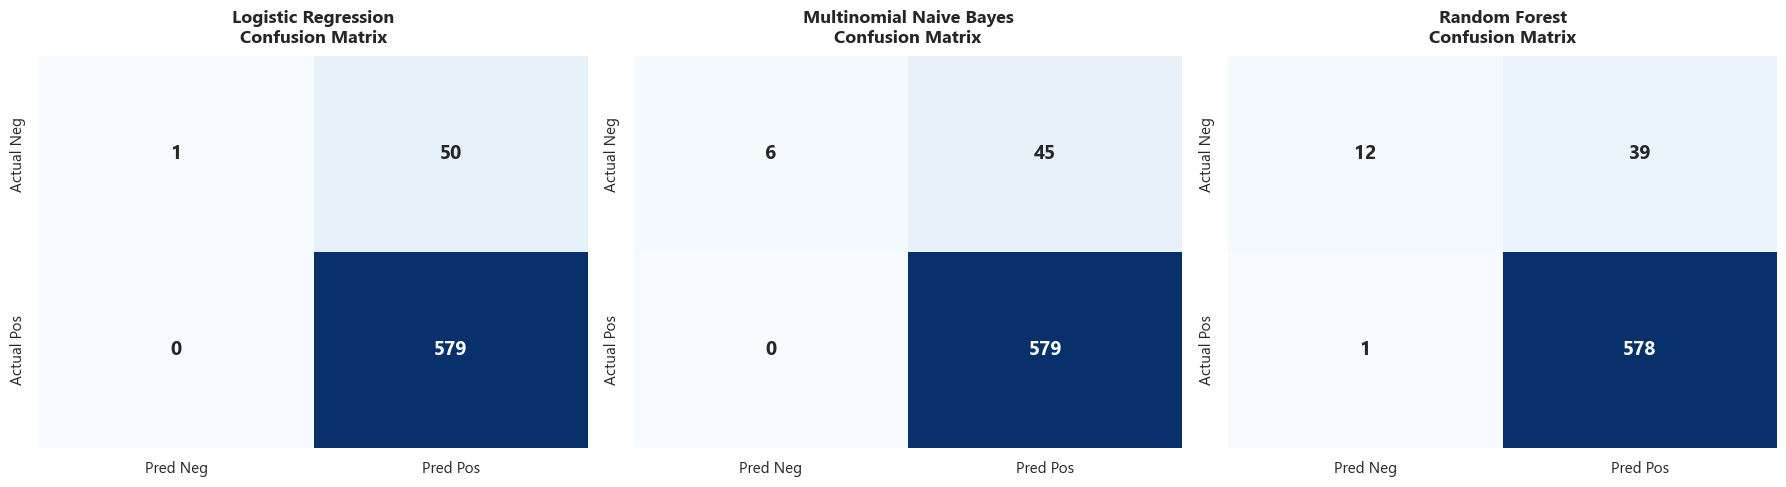

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Pred Neg', 'Pred Pos'],
                yticklabels=['Actual Neg', 'Actual Pos'],
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=13, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()


## 7. Performance Comparison & Model Persistence

We compare metrics across all models and save the best performing model along with the TF-IDF vectorizer.


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.920635,0.920509,1.000000,0.958609,0.940398
Multinomial Naive Bayes,0.928571,0.927885,1.000000,0.962594,0.900369
Random Forest,0.936508,0.936791,0.998273,0.966555,0.944648


<Figure size 1000x500 with 0 Axes>

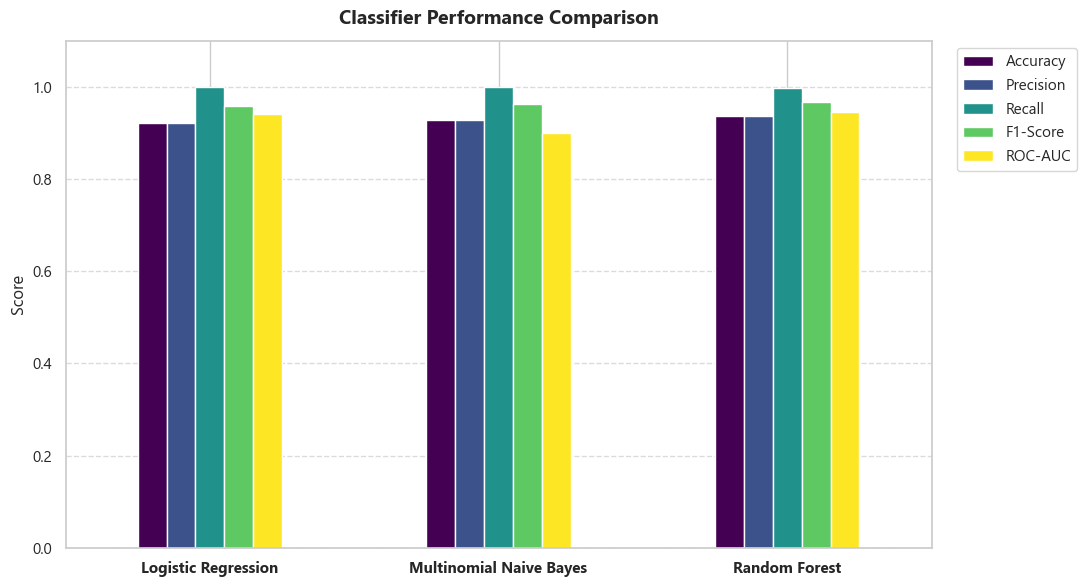

In [10]:
results_df = pd.DataFrame(results).T
display(results_df.style.highlight_max(axis=0, color='lightgreen'))

# Plot performance chart
plt.figure(figsize=(10, 5))
ax = results_df.plot(kind='bar', figsize=(11, 6), colormap='viridis')
plt.title('Classifier Performance Comparison', fontsize=14, fontweight='bold', pad=12)
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0, fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [11]:
# Determine best model based on F1-Score
best_model_name = results_df['F1-Score'].idxmax()
best_f1 = results_df.loc[best_model_name, 'F1-Score']
best_model_obj = models[best_model_name]

print(f"Top Performing Model: {best_model_name} with F1-Score of {best_f1:.4f}")

# Export best model and TF-IDF vectorizer
model_dir = os.path.join('..', 'models')
if not os.path.exists(model_dir):
    model_dir = 'models'
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, 'best_sentiment_model.pkl')
vectorizer_path = os.path.join(model_dir, 'tfidf_vectorizer.pkl')

joblib.dump(best_model_obj, model_path)
joblib.dump(vectorizer, vectorizer_path)

print(f"Saved Best Model to: {os.path.abspath(model_path)}")
print(f"Saved Vectorizer to: {os.path.abspath(vectorizer_path)}")


Top Performing Model: Random Forest with F1-Score of 0.9666


Saved Best Model to: D:\ITSimplera\Week_5\models\best_sentiment_model.pkl
Saved Vectorizer to: D:\ITSimplera\Week_5\models\tfidf_vectorizer.pkl
